In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
charts_path = '/content/drive/MyDrive/nexatel_project/charts'
os.makedirs(charts_path, exist_ok=True)

In [4]:
base_path = '/content/drive/MyDrive/nexatel_project/cleaned'
files = [f for f in os.listdir(base_path) if f.endswith('.pkl')]
dfs = {f.replace('.pkl',''): pd.read_pickle(os.path.join(base_path, f)) for f in files}

In [5]:
customers_clean = dfs['customers_clean']
plans_clean = dfs['plans_clean']
regions_clean = dfs['regions_clean']
cities_clean = dfs['cities_clean']
states_clean = dfs['states_clean']
stores_clean = dfs['stores_clean']
employees_clean = dfs['employees_clean']
subscriptions_clean = dfs['subscriptions_clean']
plan_history_clean = dfs['plan_history_clean']
contracts_clean = dfs['contracts_clean']
devices_clean = dfs['devices_clean']
billing_clean = dfs['billing_clean']
payments_clean = dfs['payments_clean']
recharges_clean = dfs['recharges_clean']
usage_voice_clean = dfs['usage_voice_clean']
usage_sms_clean = dfs['usage_sms_clean']
usage_data_clean = dfs['usage_data_clean']
network_quality_clean = dfs['network_quality_clean']
support_tickets_clean = dfs['support_tickets_clean']
complaints_clean = dfs['complaints_clean']
customer_feedback_clean = dfs['customer_feedback_clean']
retention_campaigns_clean = dfs['retention_campaigns_clean']
marketing_campaigns_clean = dfs['marketing_campaigns_clean']

In [6]:
customers_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19000 entries, 0 to 18999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          19000 non-null  object        
 1   first_name           19000 non-null  object        
 2   last_name            19000 non-null  object        
 3   gender               19000 non-null  object        
 4   date_of_birth        19000 non-null  datetime64[ns]
 5   age                  19000 non-null  int64         
 6   email                18256 non-null  object        
 7   phone_number         19000 non-null  int64         
 8   address              18620 non-null  object        
 9   city_id              19000 non-null  object        
 10  state_id             19000 non-null  object        
 11  pin_code             19000 non-null  int64         
 12  city_tier            19000 non-null  object        
 13  region_id            19000 non-

## Overall Churn Rate

In [7]:
print(customers_clean['customer_status'].value_counts())

customer_status
Active     15494
Churned     3506
Name: count, dtype: int64


In [8]:
overall_churn_rate = customers_clean['customer_status'].value_counts(normalize=True)['Churned'] * 100
print(overall_churn_rate)

18.45263157894737


In [9]:
status_counts = customers_clean['customer_status'].value_counts()
status_pct = customers_clean['customer_status'].value_counts(normalize=True) * 100

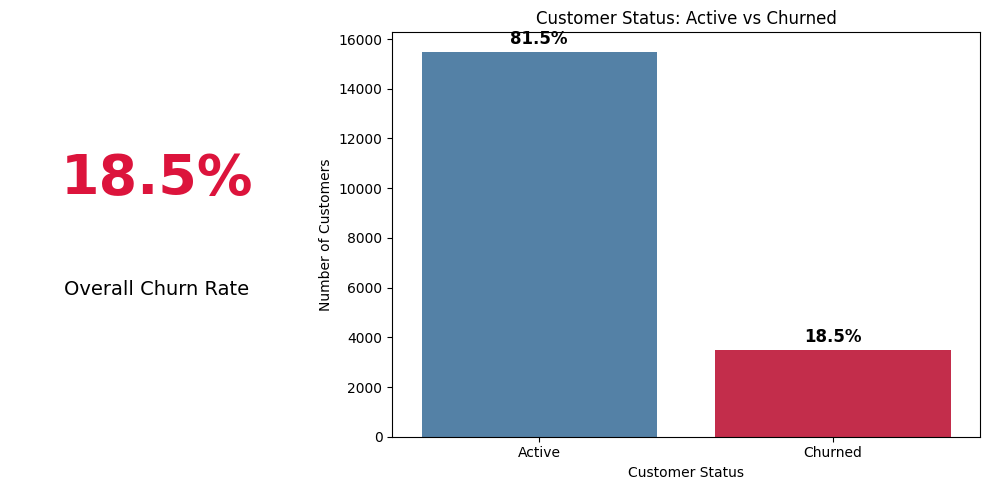

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [1, 2]})

#KPI card
axes[0].text(0.5, 0.6, f"{overall_churn_rate:.1f}%", fontsize=40, ha='center', color='crimson', fontweight='bold')
axes[0].text(0.5, 0.35, "Overall Churn Rate", fontsize=14, ha='center')
axes[0].axis('off')

#Bar chart with percentage labels
colors = {'Active': 'steelblue', 'Churned': 'crimson'}
bars = sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[1],hue=status_counts.index, palette=colors)
for i, (count, pct) in enumerate(zip(status_counts.values, status_pct.values)):
    axes[1].text(i, count + 300, f"{pct:.1f}%", ha='center', fontsize=12, fontweight='bold')

axes[1].set_title("Customer Status: Active vs Churned")
axes[1].set_xlabel("Customer Status")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.savefig(os.path.join(charts_path, 'overall_churn_rate.png'), dpi=150, bbox_inches='tight')
plt.show()

NexaTel's overall churn rate stands at 18.45%, meaning roughly 1 in every 5 customers has discontinued their service. While the majority of the customer base (81.5%) remains active, a churn rate approaching one-fifth of all customers is substantial for a subscription-based telecom business, where retaining existing customers is typically far more cost-effective than acquiring new ones. This baseline figure sets the context for the rest of the analysis — the following charts break down which customer segments, plans, and behaviors are driving this churn, to identify where retention efforts should be focused.

## Churn by Billing Cycle

In [11]:
join_billing_cycle = pd.merge(customers_clean, plans_clean, on = 'plan_id', how = 'inner')
join_billing_cycle

,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,address,city_id,...,city_name,plan_name,product_line_y,billing_cycle,monthly_charge,data_quota_gb,voice_minutes,sms_count,segment,is_active
0,C0000001,Harish,Shetty,Male,1988-03-31,38,harish.shetty909@yahoo.in,916647481156,"Plot 382, Tilak Lane, Raipur",CT0026,...,Raipur,Prepaid Smart 299,Prepaid Mobile,Monthly,299,56,-1,-1,Mass,Yes
1,C0000002,Anjali,Khan,Female,1974-03-31,52,anjali.khan525@rediffmail.com,918116536619,"Door No. 269, Civil Lines Colony, Gurugram",CT0009,...,Gurugram,Fiber Pro 1499,Fiber Broadband,Monthly,1499,5000,0,0,Premium,Yes
2,C0000003,Arjun,Hegde,Male,1978-03-31,48,arjun.hegde378@hotmail.com,918958153134,"House No. 320, Garden Nagar, Vadodara",CT0020,...,Vadodara,Enterprise Connect 4999,Enterprise,Annual,4166,8000,-1,-1,Enterprise,Yes
3,C0000004,Vidya,Parmar,Female,1988-03-31,38,vidya.parmar387@hotmail.com,917763920098,"House No. 204, Industrial Street, Nagpur",CT0015,...,Nagpur,Prepaid Annual 3599,Prepaid Mobile,Annual,300,912,-1,-1,Premium,Yes
4,C0000005,Arjun,Saxena,Male,1988-03-31,38,arjun.saxena410@yahoo.in,916787478273,"Flat 156, Krishna Sector, Warangal",CT0043,...,Warangal,Prepaid Plus 399,Prepaid Mobile,Monthly,399,84,-1,-1,Value,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18995,C0018996,Mohit,Verma,Male,1989-03-31,37,user402_at_mail,918282937457,"Villa 174, MG Nagar, Thiruvananthapuram",CT0034,...,Thiruvananthapuram,Smart Home 799,Smart Home,Monthly,799,200,0,0,Premium,Yes
18996,C0018997,Aadhya,Ahmed,Female,1969-03-31,57,aadhya.ahmed101@outlook.com,919939243608,"Apartment 215, Green Park Road, Agartala",CT0066,...,Agartala,Fiber Home 699,Fiber Broadband,Monthly,699,1500,0,0,Value,Yes
18997,C0018998,Aryan,Yadav,Male,1973-03-31,53,aryan.yadav480@outlook.com,918557275501,"Villa 273, Vivekananda Marg, Mysuru",CT0027,...,Mysuru,Postpaid Family 1299,Postpaid Mobile,Monthly,1299,300,-1,-1,Premium,Yes
18998,C0018999,Abhishek,Saxena,Male,1999-04-01,27,abhishek.saxena498@hotmail.com,919128573669,"Shop No. 119, Old Lane, Durgapur",CT0053,...,Durgapur,Prepaid Data 449,Prepaid Mobile,Monthly,449,112,-1,-1,Value,Yes


In [12]:
join_billing_cycle['product_line'] = join_billing_cycle['product_line_x']
join_billing_cycle.drop(columns = ['product_line_x', 'product_line_y'], inplace = True)
join_billing_cycle.columns.tolist()

['customer_id',
 'first_name',
 'last_name',
 'gender',
 'date_of_birth',
 'age',
 'email',
 'phone_number',
 'address',
 'city_id',
 'state_id',
 'pin_code',
 'city_tier',
 'region_id',
 'occupation',
 'annual_income_inr',
 'customer_segment',
 'plan_id',
 'acquisition_channel',
 'acquisition_date',
 'tenure_months',
 'customer_status',
 'churn_date',
 'city_name',
 'plan_name',
 'billing_cycle',
 'monthly_charge',
 'data_quota_gb',
 'voice_minutes',
 'sms_count',
 'segment',
 'is_active',
 'product_line']

In [13]:
group_billing_cycle = join_billing_cycle.groupby(['billing_cycle', 'customer_status']).size().unstack()
group_billing_cycle['churn_rate'] = group_billing_cycle['Churned'] / (group_billing_cycle['Churned'] + group_billing_cycle['Active']) * 100
group_billing_cycle

customer_status,Active,Churned,churn_rate
billing_cycle,,,
Annual,4689,362,7.166898
Monthly,10805,3144,22.539250


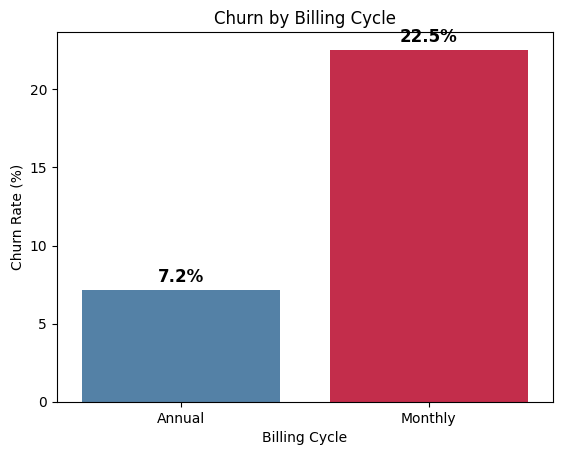

In [14]:
colors = {'Annual': 'steelblue', 'Monthly': 'crimson'}
sns.barplot(x=group_billing_cycle.index, y=group_billing_cycle['churn_rate'], hue=group_billing_cycle.index, palette=colors)

for i, rate in enumerate(group_billing_cycle['churn_rate']):
    plt.text(i, rate + 0.5, f"{rate:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.title("Churn by Billing Cycle")
plt.xlabel("Billing Cycle")
plt.ylabel("Churn Rate (%)")
plt.savefig(os.path.join(charts_path, 'churn_by_billing_cycle.png'), dpi=150, bbox_inches='tight')
plt.show()

Monthly billing customers churn at 22.5%, nearly three times the rate of Annual billing customers at 7.2%. This gap likely reflects lower switching costs and commitment for Monthly subscribers — some may be using it as a trial before committing longer-term, making it easy to leave after just one billing cycle. Annual customers, by contrast, may be more loyal by self-selection, or influenced by a sunk-cost effect from having already paid upfront for a full year.

## Churn by Tenure Band

In [15]:
join_billing_cycle['tenure_bucket'] = pd.cut(join_billing_cycle['tenure_months'], bins=[-1,3,12,36,999], labels=['0-3mo','3-12mo','1-3yr','3+ years'])
tenure_band = join_billing_cycle.groupby(['tenure_bucket','customer_status'], observed = True).size().unstack()
tenure_band['churn_rate'] = tenure_band['Churned']/(tenure_band['Active']+tenure_band['Churned'])*100
tenure_band

customer_status,Active,Churned,churn_rate
tenure_bucket,,,
0-3mo,188,561,74.899866
3-12mo,690,756,52.282158
1-3yr,1810,1026,36.177715
3+ years,12806,1163,8.325578


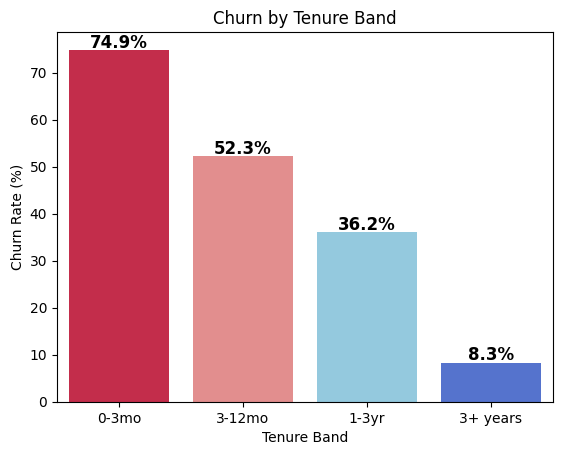

In [16]:
colors = ['crimson', 'lightcoral', 'skyblue', 'royalblue']
sns.barplot(x=tenure_band.index, y=tenure_band['churn_rate'], hue=tenure_band.index, palette=colors)

for i, rate in enumerate(tenure_band['churn_rate']):
    plt.text(i, rate + 0.5, f"{rate:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.title("Churn by Tenure Band")
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate (%)")
plt.savefig(os.path.join(charts_path, 'churn_by_tenure_band.png'), dpi=150, bbox_inches='tight')
plt.show()

Churn risk is heavily concentrated in the earliest stage of the customer relationship: customers with 0-3 months of tenure churn at 74.9%, compared to just 8.3% for customers with 3+ years — a 9x difference. The churn rate declines steadily and monotonically across every tenure band (74.9% → 52.3% → 36.2% → 8.3%), suggesting that customers who survive the initial onboarding period become progressively less likely to leave. This points to the first few months as the critical window for retention efforts, rather than spreading resources evenly across the entire customer base.

## Churn by number of Unresolved Complaints

In [17]:
unresolved = (complaints_clean[complaints_clean['status'] == 'Unresolved'].groupby('customer_id').size().reset_index(name='unresolved_complaints'))

In [18]:
join_unresolved_complaints = pd.merge(customers_clean , unresolved, on = 'customer_id', how = 'left')
join_unresolved_complaints

,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,address,city_id,...,customer_segment,product_line,plan_id,acquisition_channel,acquisition_date,tenure_months,customer_status,churn_date,city_name,unresolved_complaints
0,C0000001,Harish,Shetty,Male,1988-03-31,38,harish.shetty909@yahoo.in,916647481156,"Plot 382, Tilak Lane, Raipur",CT0026,...,Mass,Prepaid Mobile,PL002,Retail Store,2026-01-15,2,Churned,2026-03-22,Raipur,1.0
1,C0000002,Anjali,Khan,Female,1974-03-31,52,anjali.khan525@rediffmail.com,918116536619,"Door No. 269, Civil Lines Colony, Gurugram",CT0009,...,Premium,Fiber Broadband,PL017,Retail Store,2014-01-01,146,Active,NaT,Gurugram,NaN
2,C0000003,Arjun,Hegde,Male,1978-03-31,48,arjun.hegde378@hotmail.com,918958153134,"House No. 320, Garden Nagar, Vadodara",CT0020,...,Enterprise,Enterprise,PL021,Tele-sales,2015-11-11,1,Churned,2015-12-22,Vadodara,1.0
3,C0000004,Vidya,Parmar,Female,1988-03-31,38,vidya.parmar387@hotmail.com,917763920098,"House No. 204, Industrial Street, Nagpur",CT0015,...,Premium,Prepaid Mobile,PL006,Tele-sales,2014-10-18,137,Active,NaT,Nagpur,NaN
4,C0000005,Arjun,Saxena,Male,1988-03-31,38,arjun.saxena410@yahoo.in,916787478273,"Flat 156, Krishna Sector, Warangal",CT0043,...,Value,Prepaid Mobile,PL003,Online,2014-10-20,108,Churned,2023-10-22,Warangal,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18995,C0018996,Mohit,Verma,Male,1989-03-31,37,user402_at_mail,918282937457,"Villa 174, MG Nagar, Thiruvananthapuram",CT0034,...,Premium,Smart Home,PL025,Partner/Reseller,2023-03-10,36,Active,NaT,Thiruvananthapuram,NaN
18996,C0018997,Aadhya,Ahmed,Female,1969-03-31,57,aadhya.ahmed101@outlook.com,919939243608,"Apartment 215, Green Park Road, Agartala",CT0066,...,Value,Fiber Broadband,PL015,Referral,2014-11-17,136,Active,NaT,Agartala,1.0
18997,C0018998,Aryan,Yadav,Male,1973-03-31,53,aryan.yadav480@outlook.com,918557275501,"Villa 273, Vivekananda Marg, Mysuru",CT0027,...,Premium,Postpaid Mobile,PL010,Online,2023-11-08,28,Active,NaT,Mysuru,1.0
18998,C0018999,Abhishek,Saxena,Male,1999-04-01,27,abhishek.saxena498@hotmail.com,919128573669,"Shop No. 119, Old Lane, Durgapur",CT0053,...,Value,Prepaid Mobile,PL004,Referral,2015-06-30,129,Active,NaT,Durgapur,1.0


In [19]:
join_unresolved_complaints['unresolved_complaints'] = join_unresolved_complaints['unresolved_complaints'].fillna(0)

In [20]:
join_unresolved_complaints['complaint_group'] = pd.cut(join_unresolved_complaints['unresolved_complaints'], bins=[-1, 0, 1, 2, float('inf')], labels=['0', '1', '2', '3+'])

In [21]:
group_unresolved_complaints = join_unresolved_complaints.groupby(['complaint_group', 'customer_status'], observed=True).size().unstack()
group_unresolved_complaints['churn_rate'] = group_unresolved_complaints['Churned'] / (group_unresolved_complaints['Churned'] + group_unresolved_complaints['Active']) * 100
group_unresolved_complaints.sort_values(by = 'churn_rate', ascending = False)

customer_status,Active,Churned,churn_rate
complaint_group,,,
3+,77,72,48.322148
2,650,325,33.333333
1,3781,1153,23.368464
0,10986,1956,15.113584


In [22]:
print(join_unresolved_complaints['complaint_group'].value_counts().sort_index())
print(group_unresolved_complaints)

complaint_group
0     12942
1      4934
2       975
3+      149
Name: count, dtype: int64
customer_status  Active  Churned  churn_rate
complaint_group                             
0                 10986     1956   15.113584
1                  3781     1153   23.368464
2                   650      325   33.333333
3+                   77       72   48.322148


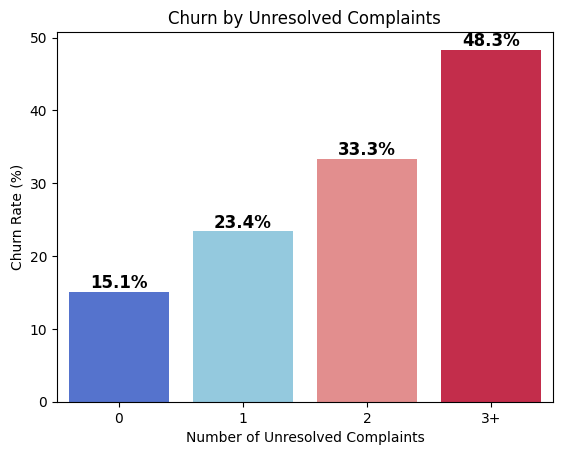

In [23]:
colors = ['royalblue', 'skyblue', 'lightcoral', 'crimson']
sns.barplot(x = group_unresolved_complaints.index, y = group_unresolved_complaints['churn_rate'], hue=group_unresolved_complaints.index, palette=colors)

for i, rate in enumerate(group_unresolved_complaints['churn_rate']):
    plt.text(i, rate + 0.5, f"{rate:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.title("Churn by Unresolved Complaints")
plt.xlabel("Number of Unresolved Complaints")
plt.ylabel("Churn Rate (%)")
plt.savefig(os.path.join(charts_path, 'Churn_by_unresolved_complaints.png'), dpi=150, bbox_inches='tight')
plt.show()

Churn rate rises steadily with the number of unresolved complaints, from 15.1% among customers with none to 49.6% among those with 3 unresolved complaints — over 3x the baseline rate. This strongly suggests unresolved complaints are a meaningful driver of churn, likely reflecting accumulated dissatisfaction from repeated unaddressed issues. The 4 and 5-complaint groups are too small (15 and 1 customers respectively) to draw reliable conclusions from, so the trend is best summarized as holding clearly through the 0-3 complaint range.

## Churn by Customer Segment

In [24]:
customers_clean['customer_segment'].value_counts()

,count
customer_segment,
Premium,8482
Value,6196
Mass,2932
Enterprise,1390


In [25]:
group_customer_segment = customers_clean.groupby(['customer_segment', 'customer_status']).size().unstack()
group_customer_segment['churn_rate'] = group_customer_segment['Churned'] / (group_customer_segment['Churned'] + group_customer_segment['Active']) * 100
group_customer_segment = group_customer_segment.sort_values(by = 'churn_rate', ascending = False)
group_customer_segment

customer_status,Active,Churned,churn_rate
customer_segment,,,
Mass,2150,782,26.671214
Value,4921,1275,20.577792
Premium,7199,1283,15.126149
Enterprise,1224,166,11.942446


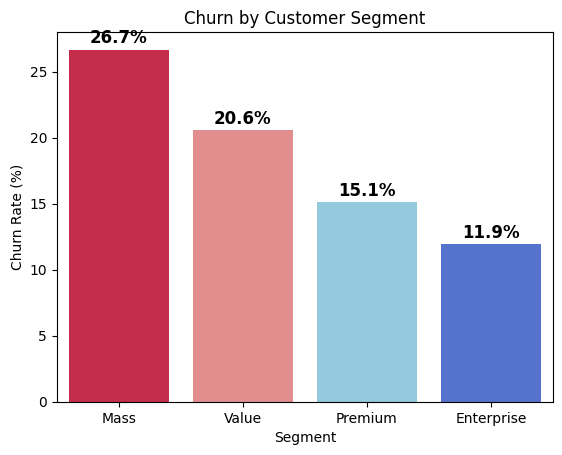

In [26]:
colors = ['crimson', 'lightcoral', 'skyblue', 'royalblue']
sns.barplot(x = group_customer_segment.index, y = group_customer_segment['churn_rate'], hue=group_customer_segment.index, palette=colors)

for i, rate in enumerate(group_customer_segment['churn_rate']):
    plt.text(i, rate + 0.5, f"{rate:.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.title("Churn by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Churn Rate (%)")
plt.savefig(os.path.join(charts_path, 'churn_by_customer_segment.png'), dpi=150, bbox_inches='tight')
plt.show()

Churn rate varies substantially by customer segment, ranging from 11.9% (Enterprise) to 26.7% (Mass) — Mass segment customers churn at more than double the rate of Enterprise customers. The ordering (Mass > Value > Premium > Enterprise) suggests churn risk decreases as customers move toward higher-value segments, likely reflecting greater brand commitment, higher switching costs, or better service levels for Premium and Enterprise customers. This indicates retention efforts may yield the highest impact if focused on the Mass segment, which has both the highest churn rate and — depending on its size — potentially the largest absolute number of at-risk customers

## Top 10 States/Circles by Churned Customers

In [27]:
join_states = pd.merge(customers_clean, states_clean, on = 'state_id', how = 'inner')
join_states

,customer_id,first_name,last_name,gender,date_of_birth,age,email,phone_number,address,city_id,...,plan_id,acquisition_channel,acquisition_date,tenure_months,customer_status,churn_date,city_name,state_name,state_code,zone
0,C0000001,Harish,Shetty,Male,1988-03-31,38,harish.shetty909@yahoo.in,916647481156,"Plot 382, Tilak Lane, Raipur",CT0026,...,PL002,Retail Store,2026-01-15,2,Churned,2026-03-22,Raipur,Chhattisgarh,CG,East
1,C0000002,Anjali,Khan,Female,1974-03-31,52,anjali.khan525@rediffmail.com,918116536619,"Door No. 269, Civil Lines Colony, Gurugram",CT0009,...,PL017,Retail Store,2014-01-01,146,Active,NaT,Gurugram,Haryana,HR,North
2,C0000003,Arjun,Hegde,Male,1978-03-31,48,arjun.hegde378@hotmail.com,918958153134,"House No. 320, Garden Nagar, Vadodara",CT0020,...,PL021,Tele-sales,2015-11-11,1,Churned,2015-12-22,Vadodara,Gujarat,GJ,West
3,C0000004,Vidya,Parmar,Female,1988-03-31,38,vidya.parmar387@hotmail.com,917763920098,"House No. 204, Industrial Street, Nagpur",CT0015,...,PL006,Tele-sales,2014-10-18,137,Active,NaT,Nagpur,Maharashtra,MH,West
4,C0000005,Arjun,Saxena,Male,1988-03-31,38,arjun.saxena410@yahoo.in,916787478273,"Flat 156, Krishna Sector, Warangal",CT0043,...,PL003,Online,2014-10-20,108,Churned,2023-10-22,Warangal,Telangana,TG,South
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18995,C0018996,Mohit,Verma,Male,1989-03-31,37,user402_at_mail,918282937457,"Villa 174, MG Nagar, Thiruvananthapuram",CT0034,...,PL025,Partner/Reseller,2023-03-10,36,Active,NaT,Thiruvananthapuram,Kerala,KL,South
18996,C0018997,Aadhya,Ahmed,Female,1969-03-31,57,aadhya.ahmed101@outlook.com,919939243608,"Apartment 215, Green Park Road, Agartala",CT0066,...,PL015,Referral,2014-11-17,136,Active,NaT,Agartala,Tripura,TR,East
18997,C0018998,Aryan,Yadav,Male,1973-03-31,53,aryan.yadav480@outlook.com,918557275501,"Villa 273, Vivekananda Marg, Mysuru",CT0027,...,PL010,Online,2023-11-08,28,Active,NaT,Mysuru,Karnataka,KA,South
18998,C0018999,Abhishek,Saxena,Male,1999-04-01,27,abhishek.saxena498@hotmail.com,919128573669,"Shop No. 119, Old Lane, Durgapur",CT0053,...,PL004,Referral,2015-06-30,129,Active,NaT,Durgapur,West Bengal,WB,East


In [28]:
group_states = join_states.groupby(['state_name','customer_status']).size().unstack()
group_states.sort_values(by = 'Churned', ascending=False)

customer_status,Active,Churned
state_name,,
Maharashtra,1571,305
Uttar Pradesh,1372,285
Tamil Nadu,1221,280
Rajasthan,1092,244
Karnataka,942,222
Gujarat,939,191
Madhya Pradesh,799,182
Kerala,699,162
Andhra Pradesh,672,160


In [29]:
top_10_states = group_states.sort_values(by = 'Churned', ascending=False).head(10)
top_10_states

customer_status,Active,Churned
state_name,,
Maharashtra,1571,305
Uttar Pradesh,1372,285
Tamil Nadu,1221,280
Rajasthan,1092,244
Karnataka,942,222
Gujarat,939,191
Madhya Pradesh,799,182
Kerala,699,162
Andhra Pradesh,672,160


In [30]:
group_states['churn_rate'] = group_states['Churned'] / (group_states['Churned'] + group_states['Active']) * 100
group_states.sort_values(by = 'churn_rate', ascending=False)

customer_status,Active,Churned,churn_rate
state_name,,,
Mizoram,118,51,30.177515
Odisha,522,144,21.621622
Tripura,131,36,21.556886
Goa,146,39,21.081081
Chandigarh,268,68,20.238095
Jammu and Kashmir,135,34,20.118343
Telangana,528,132,20.000000
Jharkhand,399,99,19.879518
Bihar,498,119,19.286872


In [31]:
group_states['churn_rate'] = group_states['Churned'] / (group_states['Churned'] + group_states['Active']) * 100
print(group_states.loc[top_10_states.index].sort_values('churn_rate', ascending=False))

customer_status  Active  Churned  churn_rate
state_name                                  
Andhra Pradesh      672      160   19.230769
West Bengal         660      157   19.216646
Karnataka           942      222   19.072165
Kerala              699      162   18.815331
Tamil Nadu         1221      280   18.654231
Madhya Pradesh      799      182   18.552497
Rajasthan          1092      244   18.263473
Uttar Pradesh      1372      285   17.199759
Gujarat             939      191   16.902655
Maharashtra        1571      305   16.257996


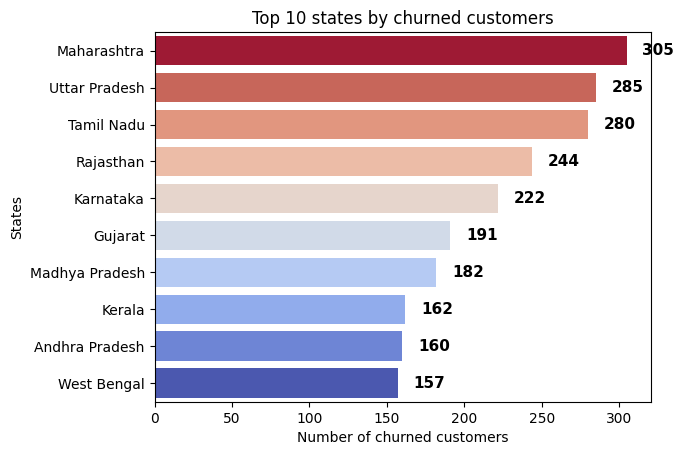

In [32]:
colors = list(plt.cm.coolwarm(np.linspace(0, 1, 10))[::-1])
sns.barplot(x = top_10_states['Churned'], y = top_10_states.index, hue = top_10_states.index, palette=colors)

for i, count in enumerate(top_10_states['Churned']):
    plt.text(count + 10, i, f"{count}", va='center', fontsize=11, fontweight='bold')

plt.title("Top 10 states by churned customers")
plt.xlabel("Number of churned customers")
plt.ylabel("States")
plt.savefig(os.path.join(charts_path, 'top_10_states_by_churned_customers.png'), dpi=150, bbox_inches='tight')
plt.show()

Maharashtra (305), Uttar Pradesh (285), and Tamil Nadu (280) have the highest absolute numbers of churned customers — but this is heavily influenced by these being NexaTel's largest states by customer base, not necessarily its riskiest. Recalculating churn as a rate reveals a different picture: smaller states like Mizoram (30.2%), Odisha (21.6%), and Tripura (21.6%) have meaningfully higher churn rates, while most of the top-10-by-count states (except Andhra Pradesh) actually rank in the bottom half by rate. This suggests two distinct retention strategies are needed: high-count states like Maharashtra warrant attention simply due to the scale of customers at risk, while high-rate states like Mizoram may have a specific, localized problem (e.g., network coverage or competition) worth investigating separately.

## Average data usage by city tier

In [33]:
join_city_tier = pd.merge(customers_clean, usage_data_clean, on = 'customer_id', how = 'inner')
print(join_city_tier.columns.tolist())
print(join_city_tier.shape)

['customer_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'age', 'email', 'phone_number', 'address', 'city_id', 'state_id', 'pin_code', 'city_tier', 'region_id', 'occupation', 'annual_income_inr', 'customer_segment', 'product_line', 'plan_id', 'acquisition_channel', 'acquisition_date', 'tenure_months', 'customer_status', 'churn_date', 'city_name', 'usage_id', 'usage_month', 'data_gb_used', 'data_sessions', 'data_usage_capped']
(57000, 30)


In [34]:
print(join_city_tier.groupby('city_tier')['customer_id'].nunique())
print(join_city_tier.groupby('city_tier').size())

city_tier
Metro     4859
Tier-2    9211
Tier-3    4930
Name: customer_id, dtype: int64
city_tier
Metro     14577
Tier-2    27633
Tier-3    14790
dtype: int64


In [35]:
rows_per_customer = join_city_tier.groupby('city_tier').size() / join_city_tier.groupby('city_tier')['customer_id'].nunique()
print(rows_per_customer)

city_tier
Metro     3.0
Tier-2    3.0
Tier-3    3.0
dtype: float64


In [36]:
group_city_tier = join_city_tier.groupby('city_tier')['data_gb_used'].mean()
group_city_tier

,data_gb_used
city_tier,
Metro,36.894050
Tier-2,27.532026
Tier-3,19.362004


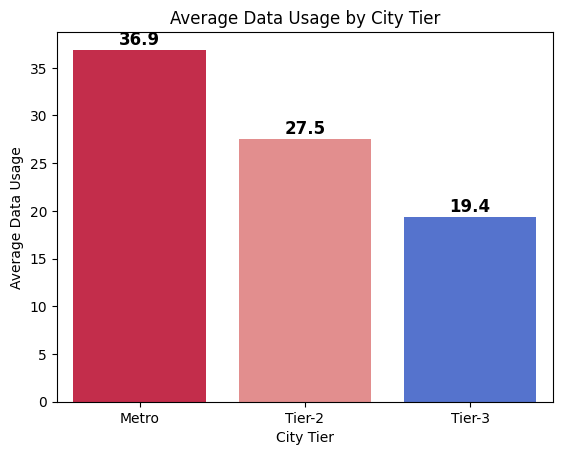

In [37]:
colors = ['crimson', 'lightcoral', 'royalblue']
sns.barplot(x = group_city_tier.index, y = group_city_tier.values, hue = group_city_tier.index, palette=colors)

for i, value in enumerate(group_city_tier.values):
    plt.text(i, value + 0.5, f"{value:.1f}", ha='center', fontsize=12, fontweight='bold')

plt.title("Average Data Usage by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Average Data Usage")
plt.savefig(os.path.join(charts_path, 'average_data_usage_by_city_tier.png'), dpi=150, bbox_inches='tight')
plt.show()

Rows-per-customer were identical across Metro, Tier-2, and Tier-3, confirming a fair like-for-like comparison. Average data usage decreases from 36.9GB in Metro to 27.5GB in Tier-2 and 19.4GB in Tier-3 cities. The higher Metro usage may reflect greater connectivity and adoption of high-speed plans, highlighting potential opportunities for infrastructure and usage growth in lower-tier cities.

## ARPU Distribution

In [38]:
active_subs = subscriptions_clean[subscriptions_clean['subscription_status'] == 'Active']
active_subs.shape

(16930, 9)

In [39]:
active_subs['customer_id'].nunique()

15674

In [40]:
group_active_subs = active_subs.groupby('customer_id')['monthly_charge_inr'].sum()
group_active_subs

,monthly_charge_inr
customer_id,
C0000002,1499.0
C0000004,1799.0
C0000006,799.0
C0000008,250.0
C0000009,899.0
...,...
C0018995,1582.0
C0018996,799.0
C0018997,699.0


In [41]:
print(group_active_subs.describe())

count    15674.000000
mean       951.915465
std       1471.827308
min         99.000000
25%        300.000000
50%        499.000000
75%        999.000000
max      16666.000000
Name: monthly_charge_inr, dtype: float64


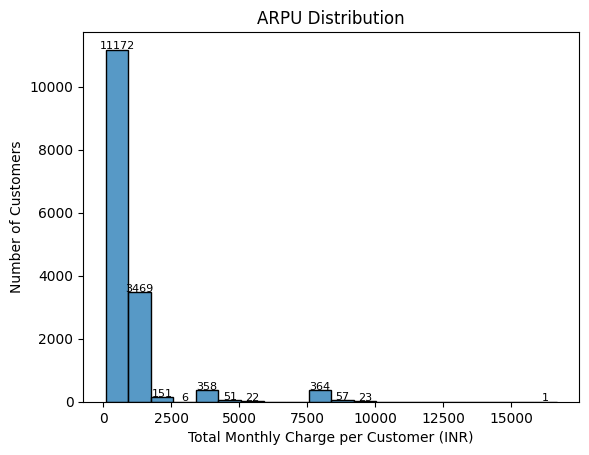

In [42]:
ax = sns.histplot(group_active_subs, bins=20)
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 20, f"{int(height)}", ha='center', fontsize=8)
plt.title("ARPU Distribution")
plt.xlabel("Total Monthly Charge per Customer (INR)")
plt.ylabel("Number of Customers")
plt.savefig(os.path.join(charts_path, 'APRU_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

ARPU was calculated using 16,930 active subscriptions, aggregated to 15,674 unique customers to account for multiple active subscriptions per customer. The average ARPU is Rs.951.92/month, while the median is Rs.499, indicating a right-skewed distribution. Most customers pay Rs.999 or less, while a smaller group of high-paying customers pulls the average upward. Therefore, Rs.499 is more representative of typical customer spending.


## Network quality vs churn

In [43]:
group_dropped_call = network_quality_clean.groupby('customer_id')['dropped_call_rate_pct'].mean()
group_dropped_call

,dropped_call_rate_pct
customer_id,
C0000001,2.763333
C0000002,3.126667
C0000003,1.426667
C0000004,1.200000
C0000005,2.433333
...,...
C0018996,3.900000
C0018997,3.840000
C0018998,2.453333


In [44]:
join_dropped_call = pd.merge(customers_clean, group_dropped_call, on = 'customer_id', how = 'inner')

In [45]:
group_network_quality = join_dropped_call.groupby('customer_status')['dropped_call_rate_pct'].mean()
group_network_quality

,dropped_call_rate_pct
customer_status,
Active,2.357718
Churned,2.594069


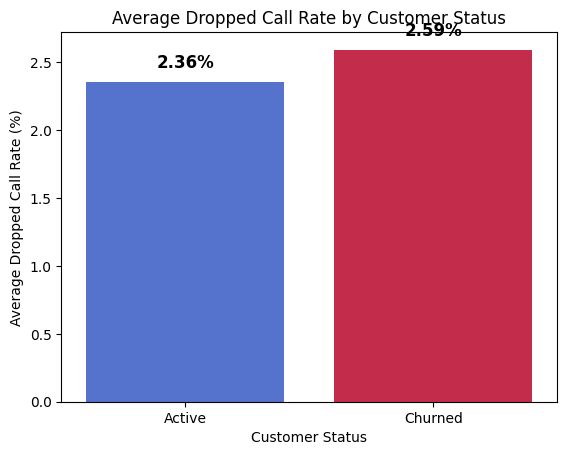

In [46]:
colors = ['royalblue', 'crimson']
sns.barplot(x=group_network_quality.index, y=group_network_quality.values, hue = group_network_quality.index, palette=colors)

for i, value in enumerate(group_network_quality.values):
    plt.text(i, value + 0.1, f"{value:.2f}%", ha='center', fontsize=12, fontweight='bold')

plt.title("Average Dropped Call Rate by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Dropped Call Rate (%)")
plt.savefig(os.path.join(charts_path, 'network_quality_vs_churn.png'), dpi=150, bbox_inches='tight')
plt.show()

Since customer status is categorical, a grouped bar chart was used to compare average dropped-call rates between Active and Churned customers. Churned customers had a slightly higher rate (2.59% vs 2.36%), a relative increase of about 10%. The modest gap suggests network quality may contribute to churn, but appears less influential than factors such as tenure and unresolved complaints.


## Retention campaign outcomes

In [47]:
retention_campaigns_clean

,campaign_id,customer_id,campaign_name,offer_type,contact_date,channel,response,retained_flag
0,RTC0000001,C0000004,Renewal Nudge,Annual Plan Discount,2025-09-04,SMS,Declined,Yes
1,RTC0000002,C0000009,Renewal Nudge,Cashback Voucher,2026-01-08,Call,Declined,Yes
2,RTC0000003,C0000015,Loyalty Save,Extra Data 50GB,2025-02-23,WhatsApp,Accepted,Yes
3,RTC0000004,C0000016,At-Risk Outreach,Free OTT 3 Months,2026-01-08,WhatsApp,Accepted,No
4,RTC0000005,C0000017,Loyalty Save,Plan Upgrade Offer,2025-05-22,Email,Accepted,No
...,...,...,...,...,...,...,...,...
6470,RTC0006471,C0018994,Win-Back Drive,Priority Support,2025-09-30,WhatsApp,Declined,Yes
6471,RTC0006472,C0018996,Value Retention,Plan Upgrade Offer,2025-08-28,SMS,Declined,Yes
6472,RTC0006473,C0018997,Value Retention,Cashback Voucher,2025-05-13,WhatsApp,Declined,Yes
6473,RTC0006474,C0018998,Win-Back Drive,Cashback Voucher,2026-02-27,SMS,Accepted,Yes


In [48]:
group_camp = retention_campaigns_clean.groupby('response')['customer_id'].count()
group_camp

,customer_id
response,
Accepted,2982
Declined,1877
No Response,1616


In [49]:
retained = retention_campaigns_clean[retention_campaigns_clean['retained_flag'] == 'Yes'].count()['customer_id']
total = retention_campaigns_clean.count()['customer_id']
retained_share = (retained/total)*100
print(retained)
print(total)
print(retained_share)

5337
6475
82.42471042471043


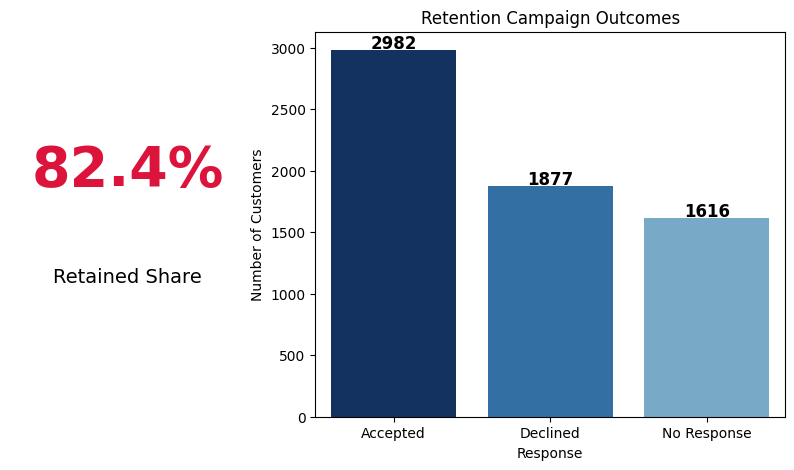

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [1, 2]})

axes[0].text(0.5, 0.6, f"{retained_share:.1f}%", fontsize=40, ha='center', color='crimson', fontweight='bold')
axes[0].text(0.5, 0.35, "Retained Share", fontsize=14, ha='center')
axes[0].axis('off')

colors = list(plt.cm.Blues(np.linspace(0.5, 1, 3))[::-1])
sns.barplot(x=group_camp.index, y=group_camp.values, hue=group_camp.index, palette=colors)
for i, value in enumerate(group_camp.values):
    plt.text(i, value + 10, f"{value}", ha='center', fontsize=12, fontweight='bold')

plt.title("Retention Campaign Outcomes")
plt.xlabel("Response")
plt.ylabel("Number of Customers")
plt.savefig(os.path.join(charts_path, 'retention_campaign_outcomes.png'), dpi=150, bbox_inches='tight')
plt.show()

We have 1,877 declined retention campaign responses and 1,616 no-response cases, while the largest group — 2,982 customers — accepted the offer. Overall, 82.4% of all targeted customers were ultimately retained.